# 02 — Pareto frontier: λ sweep on Agents C and C+

Inputs: `results/metrics/pareto/run_metrics.csv` (2 agents × 6 λ × 3 vol × 30 seeds = 1,080 runs at fixed toxicity=10, solo competition).

The inventory penalty `λ · q²` enters the agents' reward shaping. Sweeping λ traces the frontier between expected PnL and inventory variance — the larger λ, the more aggressively the agent flattens its book at the expense of revenue.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "pyproject.toml").exists() or (cand / "src/lob_market_making_agents").exists():
            return cand
    return here

REPO_ROOT = _find_repo_root()
src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from lob_market_making_agents.analysis.plots import (
    VOL_ORDER, agent_palette, parse_lambda_label, save_figure,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 144, "axes.grid": True, "grid.alpha": 0.3})

PARETO_CSV = REPO_ROOT / "results/metrics/pareto/run_metrics.csv"
FIG_DIR = REPO_ROOT / "results/figures/pareto"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(PARETO_CSV)
df["lam"] = df.config_name.map(parse_lambda_label)
assert df.lam.notna().all(), "λ extraction failed for some rows"
print("rows:", len(df), "  lambdas:", sorted(df.lam.unique()), "  agents:", sorted(df.agent.unique()))
assert len(df) == 1080

rows: 1080   lambdas: [np.float64(0.0), np.float64(0.001), np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.5)]   agents: ['C', 'C_PLUS']


## Frontier per agent (one panel each)

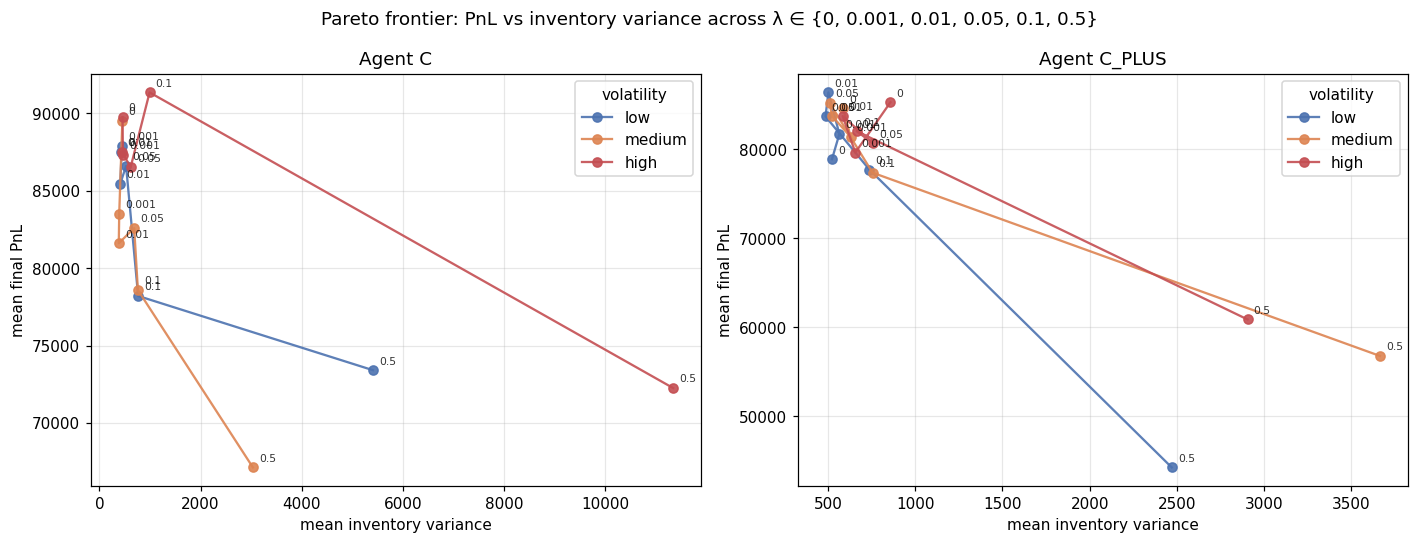

In [3]:
agg = df.groupby(["agent", "lam", "volatility"]).agg(
    pnl_mean=("final_pnl", "mean"),
    pnl_sem=("final_pnl", "sem"),
    invvar_mean=("inventory_var", "mean"),
).reset_index()


def panel(ax, agent: str):
    palette = {"low": "#4C72B0", "medium": "#DD8452", "high": "#C44E52"}
    sub = agg[agg.agent == agent].sort_values("lam")
    for vol in VOL_ORDER:
        line = sub[sub.volatility == vol]
        ax.plot(line.invvar_mean, line.pnl_mean, "-o", color=palette[vol], label=vol, alpha=0.9)
        for _, row in line.iterrows():
            ax.annotate(f"{row.lam:g}", (row.invvar_mean, row.pnl_mean), fontsize=7, alpha=0.8,
                        xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("mean inventory variance")
    ax.set_ylabel("mean final PnL")
    ax.set_title(f"Agent {agent}")
    ax.legend(title="volatility")


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
panel(axes[0], "C")
panel(axes[1], "C_PLUS")
fig.suptitle("Pareto frontier: PnL vs inventory variance across λ ∈ {0, 0.001, 0.01, 0.05, 0.1, 0.5}", fontsize=12)
save_figure(fig, FIG_DIR / "frontier_per_agent.png")
plt.show()

## Overlay: C vs C+ on one axis per volatility level

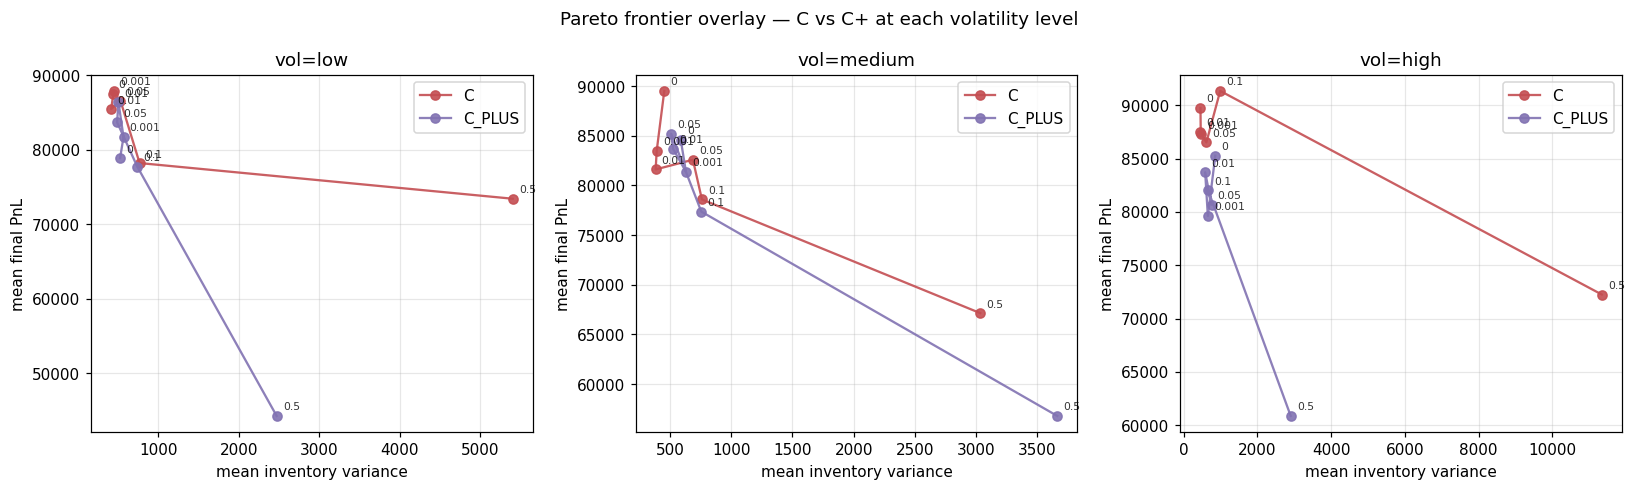

In [4]:
fig, axes = plt.subplots(1, len(VOL_ORDER), figsize=(15, 4.5), sharey=False)
palette = agent_palette()
for ax, vol in zip(axes, VOL_ORDER):
    for agent in ("C", "C_PLUS"):
        line = agg[(agg.agent == agent) & (agg.volatility == vol)].sort_values("lam")
        ax.plot(line.invvar_mean, line.pnl_mean, "-o", color=palette[agent], label=agent, alpha=0.9)
        for _, row in line.iterrows():
            ax.annotate(f"{row.lam:g}", (row.invvar_mean, row.pnl_mean), fontsize=7, alpha=0.8,
                        xytext=(4, 4), textcoords="offset points")
    ax.set_title(f"vol={vol}")
    ax.set_xlabel("mean inventory variance")
    ax.set_ylabel("mean final PnL")
    ax.legend()
fig.suptitle("Pareto frontier overlay — C vs C+ at each volatility level", fontsize=12)
save_figure(fig, FIG_DIR / "frontier_overlay.png")
plt.show()

## Knee λ per (agent, volatility)

Score: `PnL − k · sqrt(inventory_var)`, with `k = 1.0` (one PnL unit per unit of inventory standard deviation). The knee λ is the maximiser of this score along each frontier.

In [5]:
K = 1.0
agg["score"] = agg.pnl_mean - K * np.sqrt(agg.invvar_mean)
knees = (agg.sort_values("score", ascending=False)
            .groupby(["agent", "volatility"], as_index=False).head(1)
            .sort_values(["agent", "volatility"]))
out = REPO_ROOT / "results/metrics/pareto/knee_lambda.csv"
knees.to_csv(out, index=False)
print("wrote", out)
knees.round(3)

wrote /Users/lewis/Documents/Work/LOB Market Maker Agents/LOB-Market-Making-Agents/results/metrics/pareto/knee_lambda.csv


,agent,lam,volatility,pnl_mean,pnl_sem,invvar_mean,score
12,C,0.100,high,91339.401,5709.656,991.727,91307.909
4,C,0.001,low,87883.079,2754.913,444.915,87861.986
2,C,0.000,medium,89512.240,3519.299,453.185,89490.952
18,C_PLUS,0.000,high,85268.445,3249.181,858.447,85239.146
25,C_PLUS,0.010,low,86367.477,3592.715,502.466,86345.061
29,C_PLUS,0.050,medium,85194.415,2537.580,509.694,85171.839
